# CAVS: Basic Coasting

This Connected Automated Vehicle (CAV) demo shows coasting behavior using
a simple speed threshold. When the vehicle reaches the threshold speed, it
coasts to a stop.

In [1]:
import os

import seaborn as sns

import sys
from pathlib import Path

import fastsim as fsim
from plot_utils import plot_speed_by_time, plot_speed_by_dist

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Setup

Load a vehicle and cycle. The cycle is extended to allow extra time for
coasting delays. A copy of the original cycle is kept for comparison.

In [3]:
coast_speed_mps = 20.0

veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

cyc = fsim.Cycle.from_resource("udds.csv")
end_idle_duration_s = cyc.ending_idle_time_s()
cyc = cyc.extend_time(absolute_time_s=120.0, time_fraction=None)
cyc0 = cyc.copy()

## Apply Coasting Maneuver

`Maneuver` modifies the cycle based on coasting parameters. Setting
`coast_start_speed_meters_per_second` causes the vehicle to coast to a
stop whenever it reaches that speed.

In [4]:
man = fsim.Maneuver.create_from(cyc, veh.copy())
d = man.to_pydict()
d["coast_allow"] = True
d["coast_start_speed_meters_per_second"] = coast_speed_mps
man = fsim.Maneuver.from_pydict(d)

cyc = man.apply_maneuvers()
cyc = cyc.trim_ending_idle(idle_to_keep_s=end_idle_duration_s)

In [5]:
sd = fsim.SimDrive(veh, cyc)
sd.walk()

## Results

Original cycle speed vs. achieved speed with coasting applied.

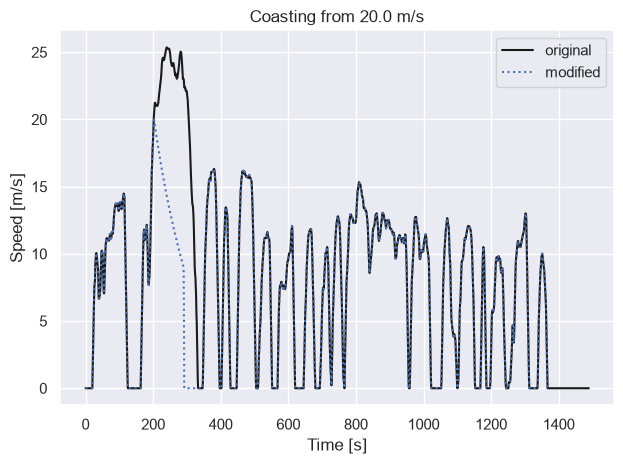

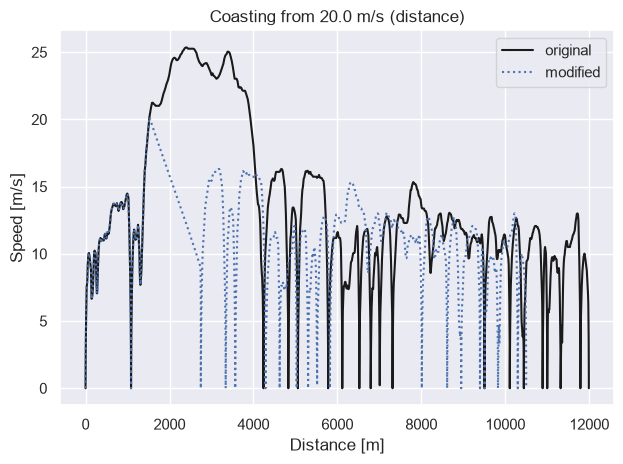

In [6]:
if SHOW_PLOTS:
    c0 = cyc0.to_pydict()
    df = sd.to_dataframe()
    plot_speed_by_time(df, c0, title=f"Coasting from {coast_speed_mps} m/s",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)
    plot_speed_by_dist(df, c0, title=f"Coasting from {coast_speed_mps} m/s (distance)",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)